# Importing

## Import Library

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kylefengkfeng209/how-fast-do-you-forget-13m-duolingo-sessions/language_courses.csv
/kaggle/input/datasets/kylefengkfeng209/how-fast-do-you-forget-13m-duolingo-sessions/forgetting_curve.csv
/kaggle/input/datasets/kylefengkfeng209/how-fast-do-you-forget-13m-duolingo-sessions/word_difficulty.csv
/kaggle/input/datasets/kylefengkfeng209/how-fast-do-you-forget-13m-duolingo-sessions/learning_traces_sample.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('/kaggle/input/datasets/kylefengkfeng209/how-fast-do-you-forget-13m-duolingo-sessions/forgetting_curve.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,learning_language,language_name,lag_bin,lag_bin_order,practice_bin,practice_bin_order,n_traces,avg_session_recall,item_recall_rate,pct_perfect_sessions
0,all,All languages,<1 hour,0,1-2 exposures,0,383261,0.9157,0.9191,87.37
1,all,All languages,<1 hour,0,3-4 exposures,1,893452,0.9137,0.9177,86.26
2,all,All languages,<1 hour,0,5-9 exposures,2,1429269,0.9129,0.9186,86.50
3,all,All languages,<1 hour,0,10-19 exposures,3,1023779,0.9129,0.9199,86.00
4,all,All languages,<1 hour,0,20+ exposures,4,1239541,0.8995,0.9097,84.58


## last Five row

In [4]:
df.tail()

,learning_language,language_name,lag_bin,lag_bin_order,practice_bin,practice_bin_order,n_traces,avg_session_recall,item_recall_rate,pct_perfect_sessions
305,pt,Portuguese,3+ months,8,1-2 exposures,0,386,0.8765,0.8775,80.05
306,pt,Portuguese,3+ months,8,3-4 exposures,1,812,0.8670,0.8776,77.71
307,pt,Portuguese,3+ months,8,5-9 exposures,2,670,0.8805,0.8791,79.55
308,pt,Portuguese,3+ months,8,10-19 exposures,3,351,0.8649,0.8764,77.21
309,pt,Portuguese,3+ months,8,20+ exposures,4,63,0.8791,0.8923,79.37


## Shape of our dataset

In [5]:
df.shape

(310, 10)

## List out all columns

In [6]:
df.columns

Index(['learning_language', 'language_name', 'lag_bin', 'lag_bin_order',
       'practice_bin', 'practice_bin_order', 'n_traces', 'avg_session_recall',
       'item_recall_rate', 'pct_perfect_sessions'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

learning_language        object
language_name            object
lag_bin                  object
lag_bin_order             int64
practice_bin             object
practice_bin_order        int64
n_traces                  int64
avg_session_recall      float64
item_recall_rate        float64
pct_perfect_sessions    float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   learning_language     310 non-null    object 
 1   language_name         310 non-null    object 
 2   lag_bin               310 non-null    object 
 3   lag_bin_order         310 non-null    int64  
 4   practice_bin          310 non-null    object 
 5   practice_bin_order    310 non-null    int64  
 6   n_traces              310 non-null    int64  
 7   avg_session_recall    310 non-null    float64
 8   item_recall_rate      310 non-null    float64
 9   pct_perfect_sessions  310 non-null    float64
dtypes: float64(3), int64(3), object(4)
memory usage: 24.3+ KB


## Check Null Value

In [9]:
df.isnull().sum()

learning_language       0
language_name           0
lag_bin                 0
lag_bin_order           0
practice_bin            0
practice_bin_order      0
n_traces                0
avg_session_recall      0
item_recall_rate        0
pct_perfect_sessions    0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,lag_bin_order,practice_bin_order,n_traces,avg_session_recall,item_recall_rate,pct_perfect_sessions
count,310.000000,310.0000,3.100000e+02,310.000000,310.000000,310.000000
mean,3.935484,2.0000,8.293049e+04,0.888834,0.897956,83.082161
std,2.555981,1.4165,1.573597e+05,0.017793,0.014307,2.836484
min,0.000000,0.0000,6.300000e+01,0.818100,0.851800,72.610000
25%,2.000000,1.0000,1.186825e+04,0.878000,0.888025,81.532500
50%,4.000000,2.0000,3.324150e+04,0.889200,0.898500,83.260000
75%,6.000000,3.0000,8.646775e+04,0.900050,0.905850,84.677500
max,8.000000,4.0000,1.429269e+06,0.932900,0.933700,90.170000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

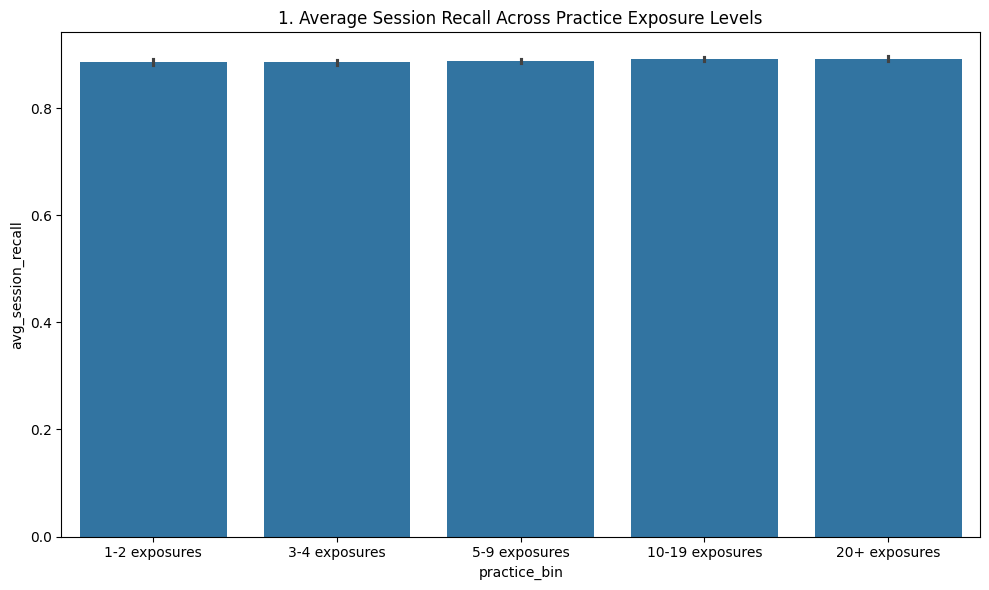

In [13]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='practice_bin', y='avg_session_recall', order=df.sort_values('practice_bin_order')['practice_bin'].unique())
plt.title(f'{plot_no}. Average Session Recall Across Practice Exposure Levels')
show_fig()
plot_no += 1

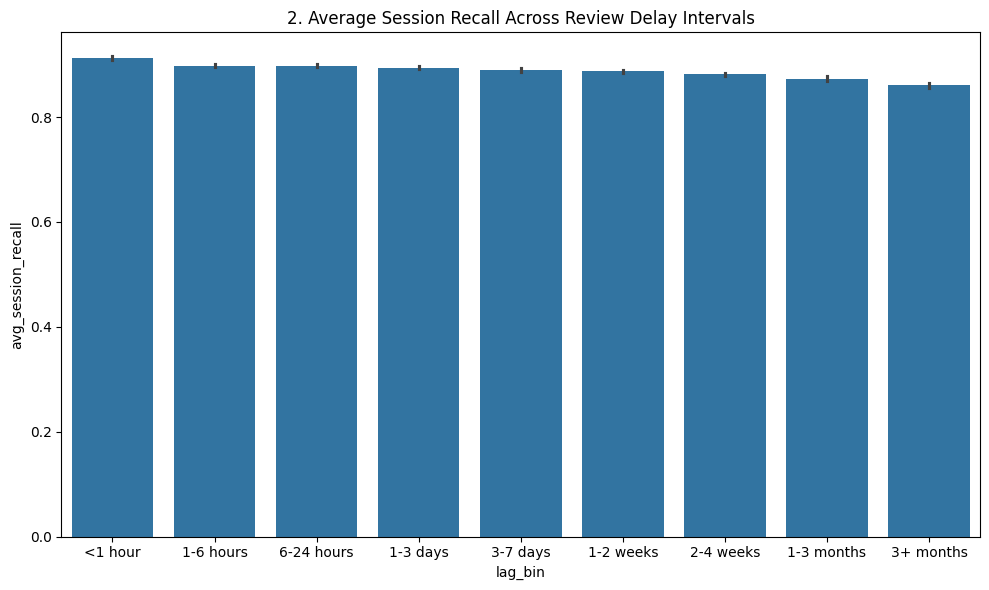

In [14]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='lag_bin', y='avg_session_recall', order=df.sort_values('lag_bin_order')['lag_bin'].unique())
plt.title(f'{plot_no}. Average Session Recall Across Review Delay Intervals')
show_fig()
plot_no += 1

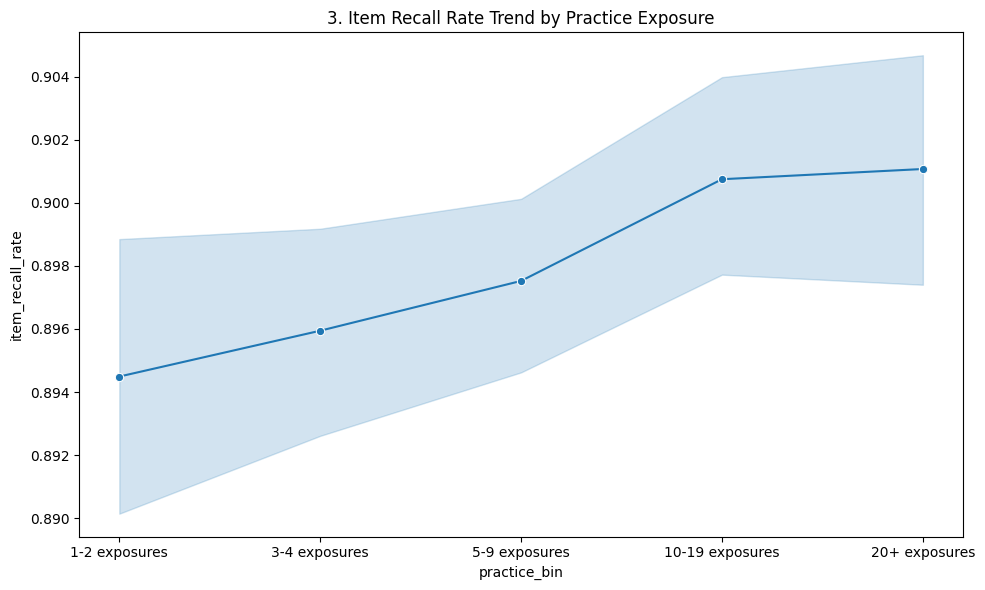

In [15]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=df.sort_values('practice_bin_order'), x='practice_bin', y='item_recall_rate', marker='o')
plt.title(f'{plot_no}. Item Recall Rate Trend by Practice Exposure')
show_fig()
plot_no += 1

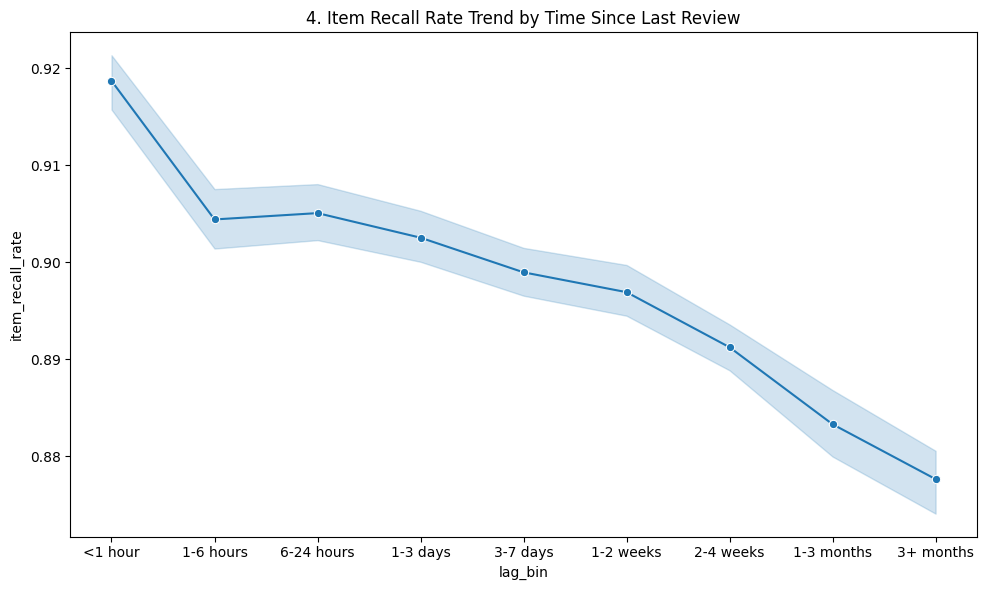

In [16]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=df.sort_values('lag_bin_order'), x='lag_bin', y='item_recall_rate', marker='o')
plt.title(f'{plot_no}. Item Recall Rate Trend by Time Since Last Review')
show_fig()
plot_no += 1

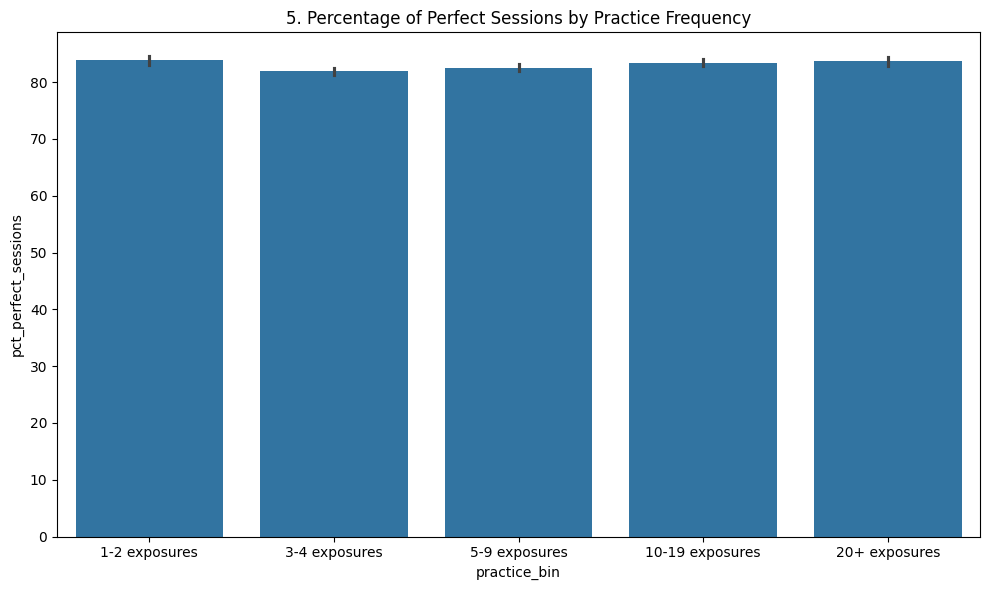

In [17]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='practice_bin', y='pct_perfect_sessions', order=df.sort_values('practice_bin_order')['practice_bin'].unique())
plt.title(f'{plot_no}. Percentage of Perfect Sessions by Practice Frequency')
show_fig()
plot_no += 1

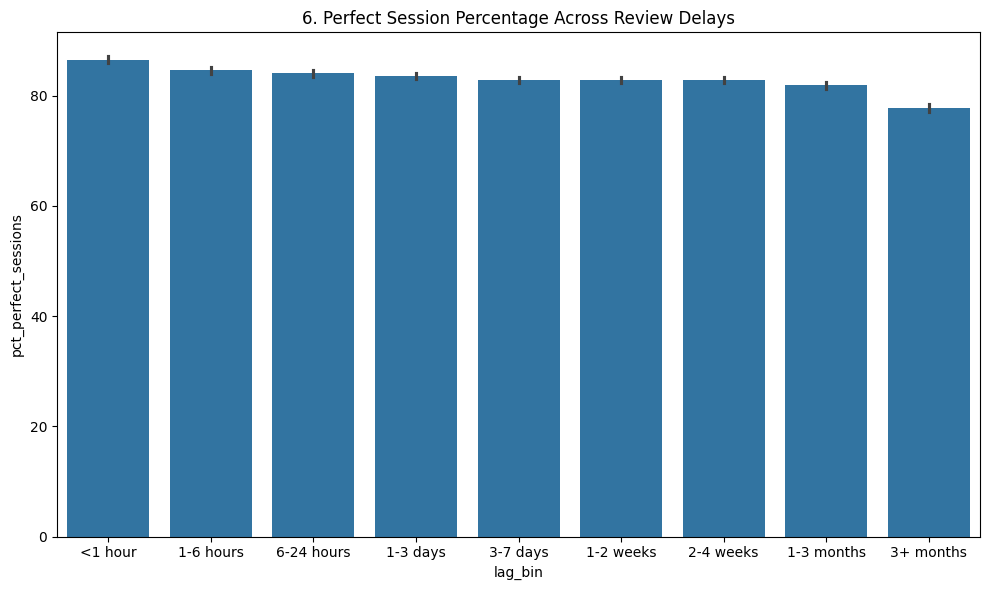

In [18]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='lag_bin', y='pct_perfect_sessions', order=df.sort_values('lag_bin_order')['lag_bin'].unique())
plt.title(f'{plot_no}. Perfect Session Percentage Across Review Delays')
show_fig()
plot_no += 1

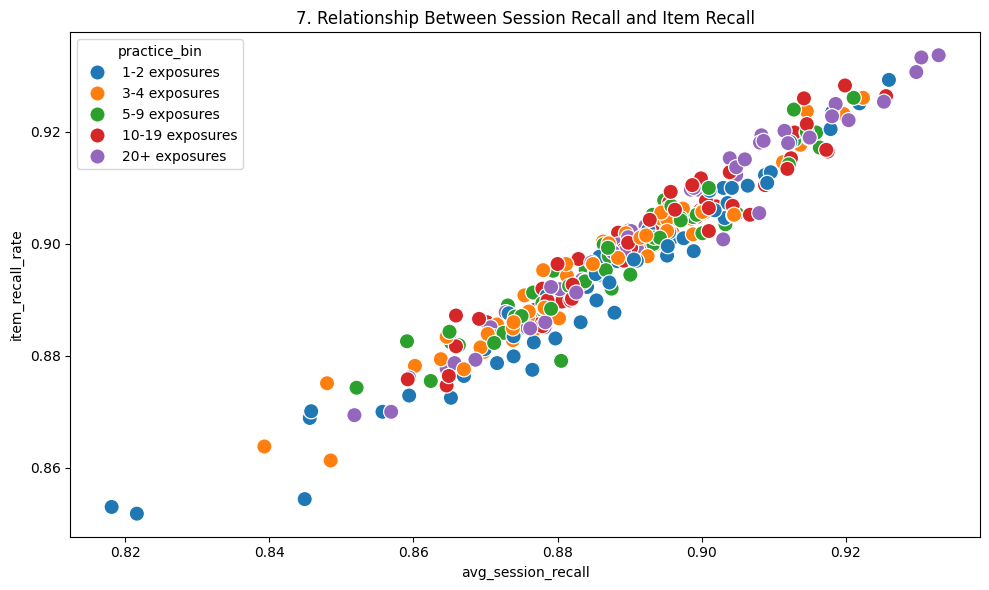

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='avg_session_recall', y='item_recall_rate', hue='practice_bin', s=120)
plt.title(f'{plot_no}. Relationship Between Session Recall and Item Recall')
show_fig()
plot_no += 1

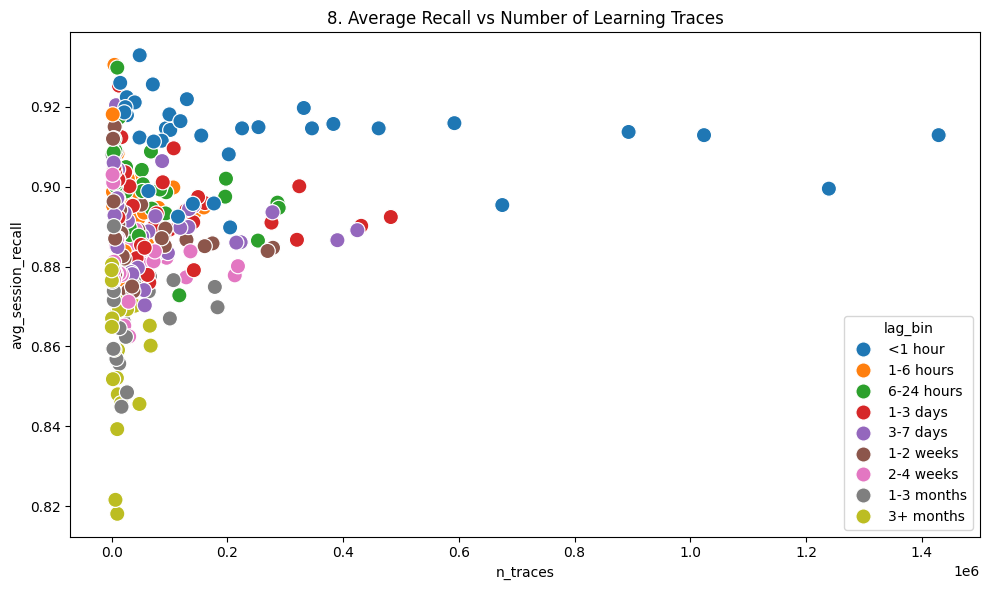

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='n_traces', y='avg_session_recall', hue='lag_bin', s=120)
plt.title(f'{plot_no}. Average Recall vs Number of Learning Traces')
show_fig()
plot_no += 1

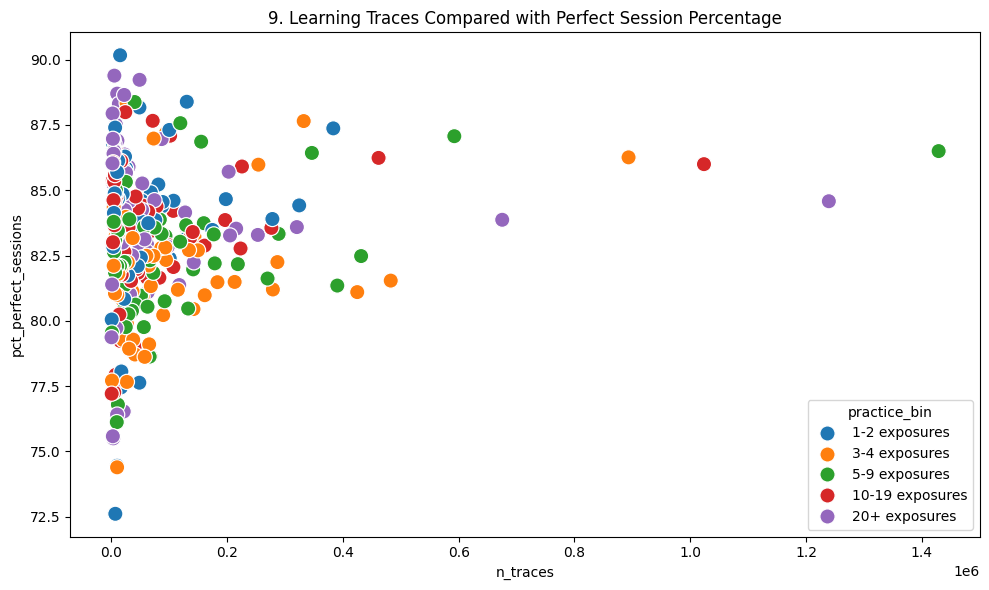

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='n_traces', y='pct_perfect_sessions', hue='practice_bin', s=120)
plt.title(f'{plot_no}. Learning Traces Compared with Perfect Session Percentage')
show_fig()
plot_no += 1

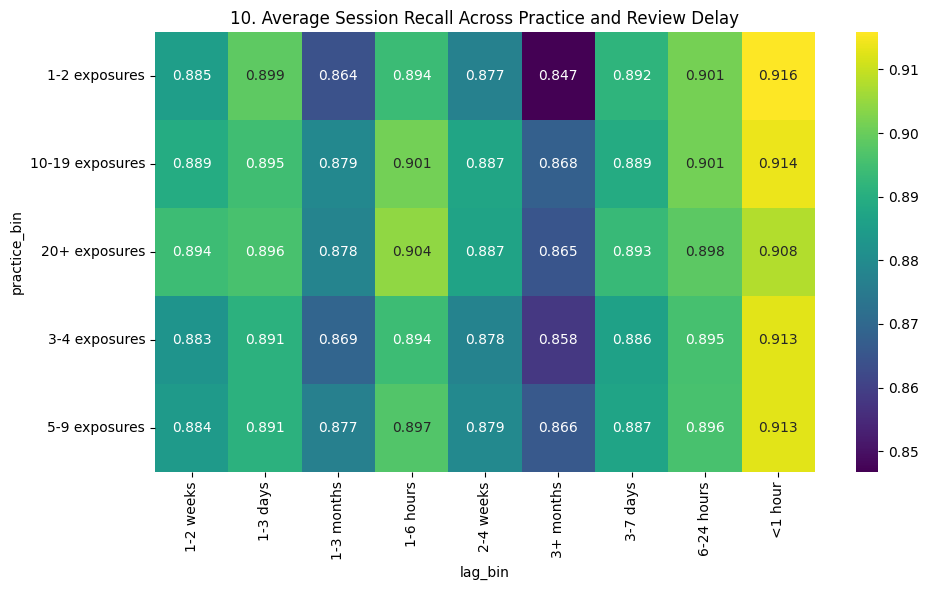

In [22]:
fig = plt.figure(figsize=(10,6))
pivot = df.pivot_table(index='practice_bin', columns='lag_bin', values='avg_session_recall')
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis')
plt.title(f'{plot_no}. Average Session Recall Across Practice and Review Delay')
show_fig()
plot_no += 1

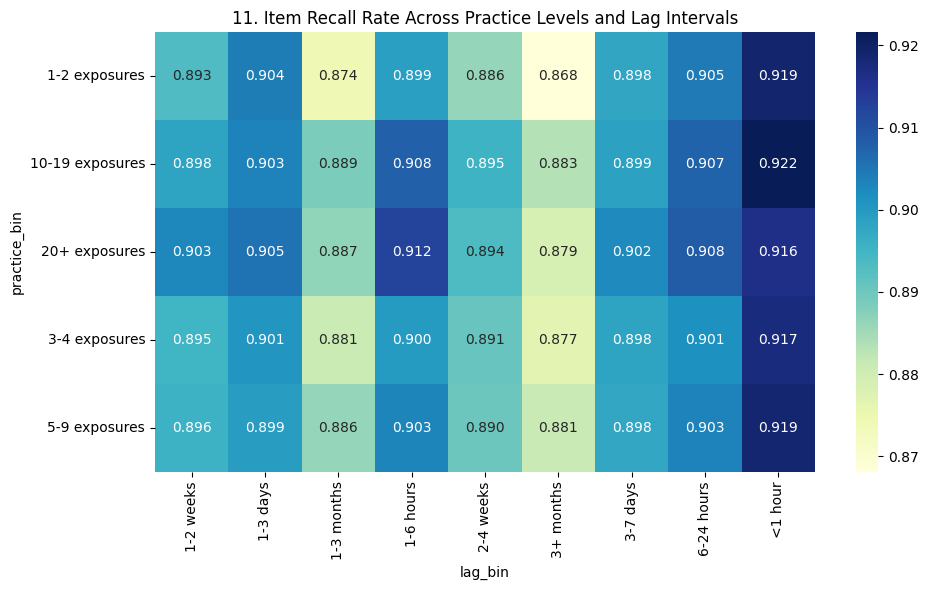

In [23]:
fig = plt.figure(figsize=(10,6))
pivot = df.pivot_table(index='practice_bin', columns='lag_bin', values='item_recall_rate')
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu')
plt.title(f'{plot_no}. Item Recall Rate Across Practice Levels and Lag Intervals')
show_fig()
plot_no += 1

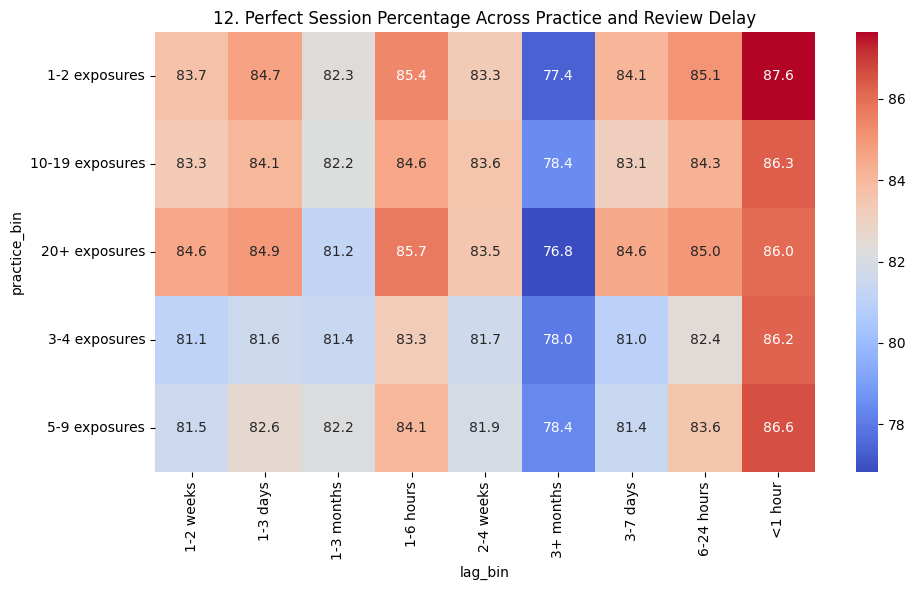

In [24]:
fig = plt.figure(figsize=(10,6))
pivot = df.pivot_table(index='practice_bin', columns='lag_bin', values='pct_perfect_sessions')
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='coolwarm')
plt.title(f'{plot_no}. Perfect Session Percentage Across Practice and Review Delay')
show_fig()
plot_no += 1

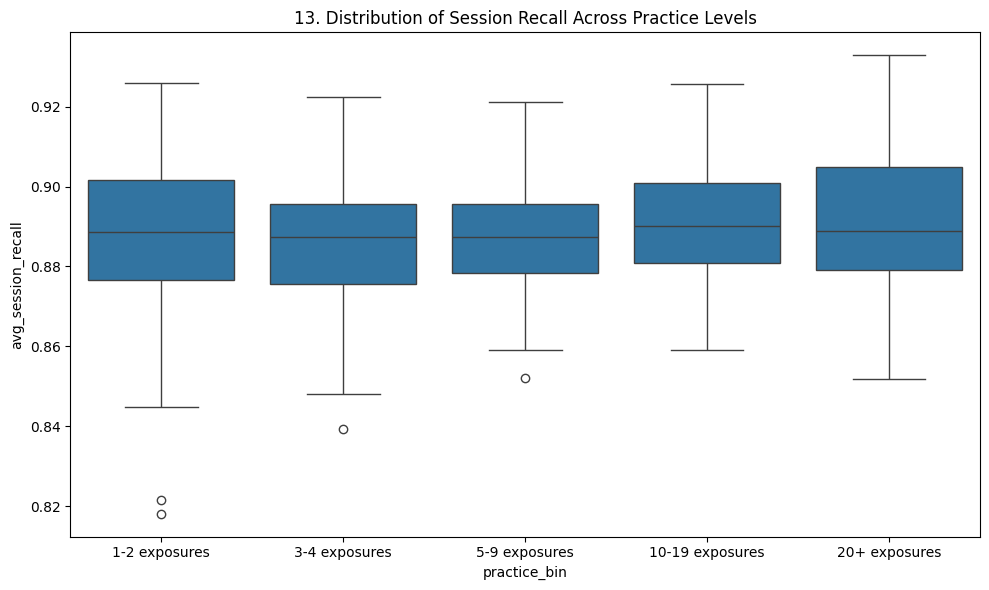

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='practice_bin', y='avg_session_recall', order=df.sort_values('practice_bin_order')['practice_bin'].unique())
plt.title(f'{plot_no}. Distribution of Session Recall Across Practice Levels')
show_fig()
plot_no += 1

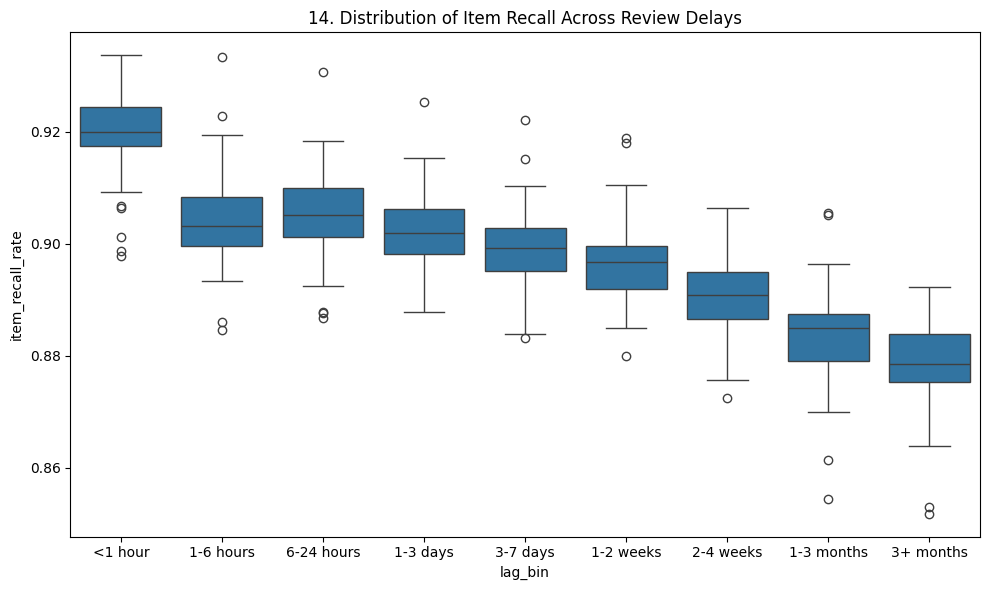

In [26]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='lag_bin', y='item_recall_rate', order=df.sort_values('lag_bin_order')['lag_bin'].unique())
plt.title(f'{plot_no}. Distribution of Item Recall Across Review Delays')
show_fig()
plot_no += 1

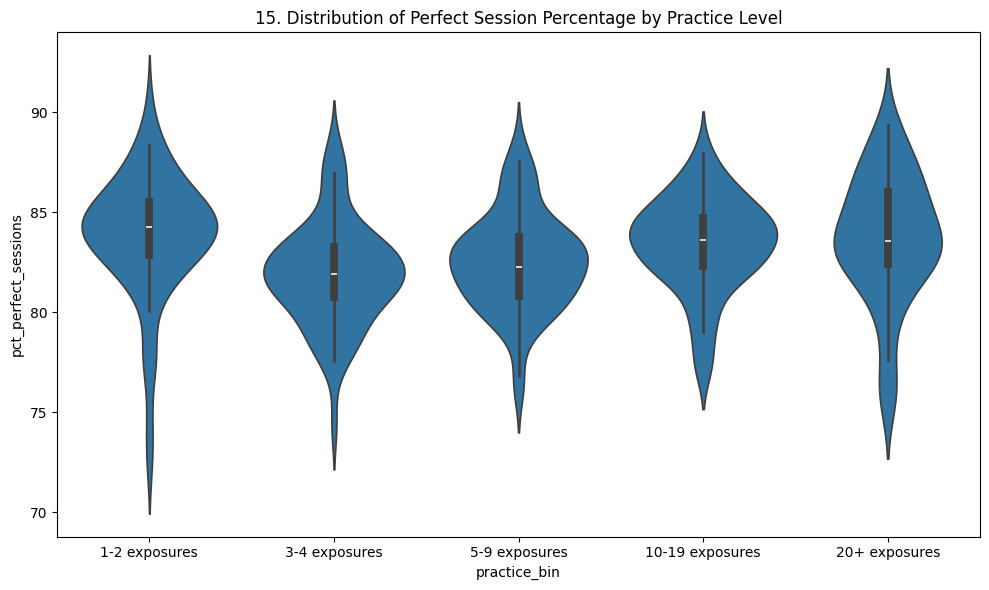

In [27]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='practice_bin', y='pct_perfect_sessions', order=df.sort_values('practice_bin_order')['practice_bin'].unique())
plt.title(f'{plot_no}. Distribution of Perfect Session Percentage by Practice Level')
show_fig()
plot_no += 1

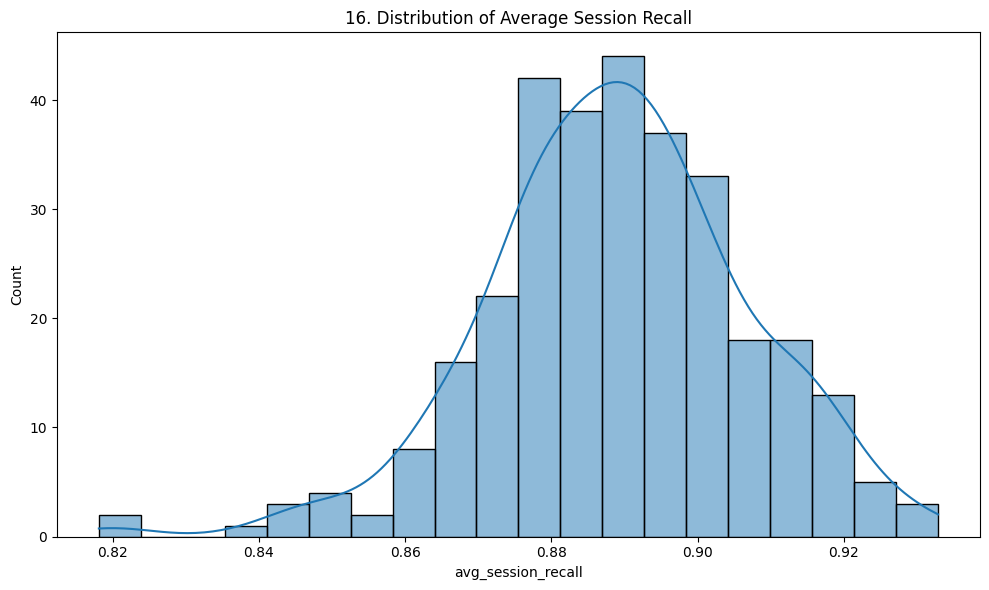

In [28]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='avg_session_recall', bins=20, kde=True)
plt.title(f'{plot_no}. Distribution of Average Session Recall')
show_fig()
plot_no += 1

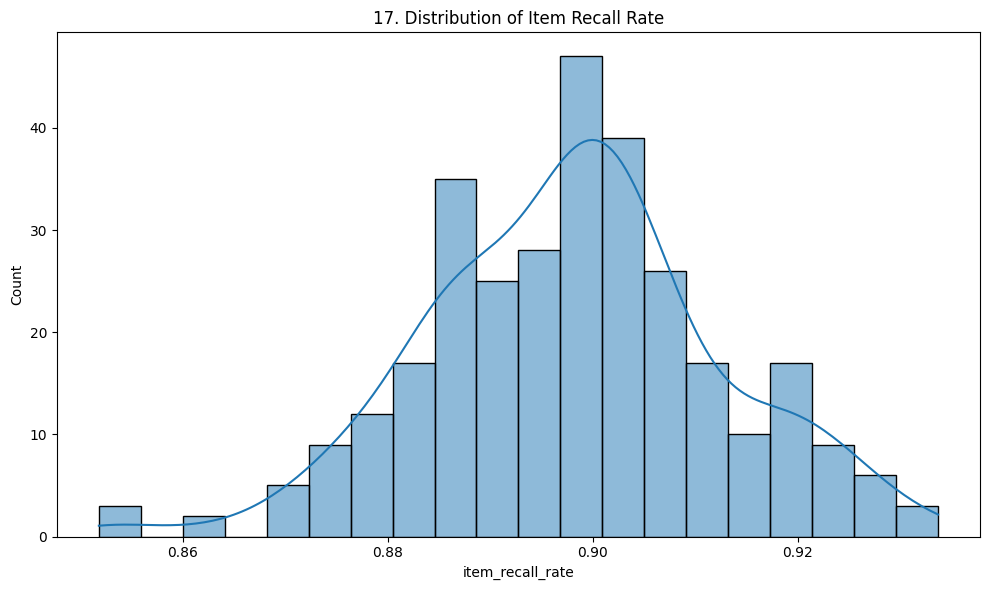

In [29]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='item_recall_rate', bins=20, kde=True)
plt.title(f'{plot_no}. Distribution of Item Recall Rate')
show_fig()
plot_no += 1

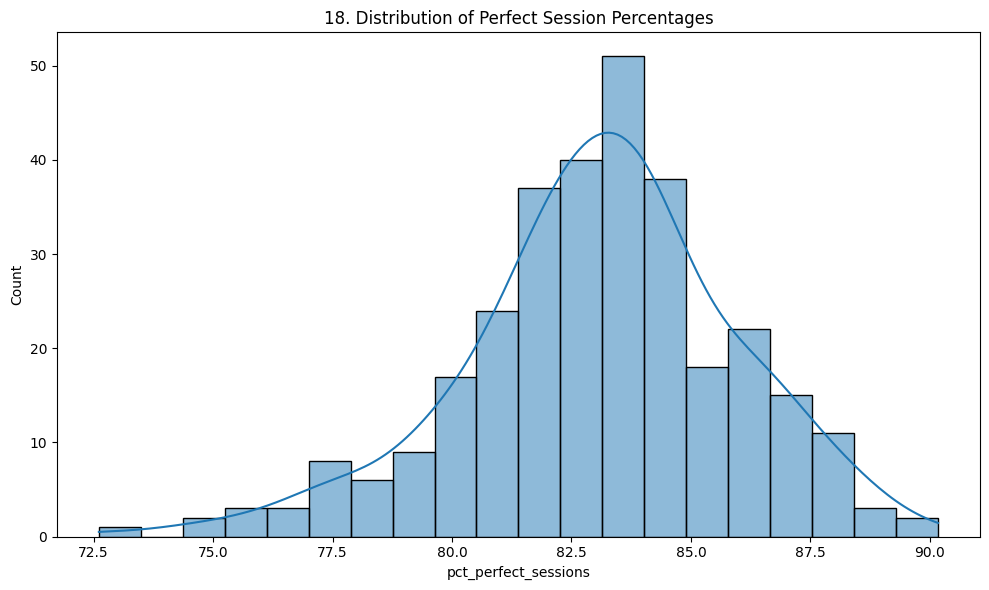

In [30]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='pct_perfect_sessions', bins=20, kde=True)
plt.title(f'{plot_no}. Distribution of Perfect Session Percentages')
show_fig()
plot_no += 1

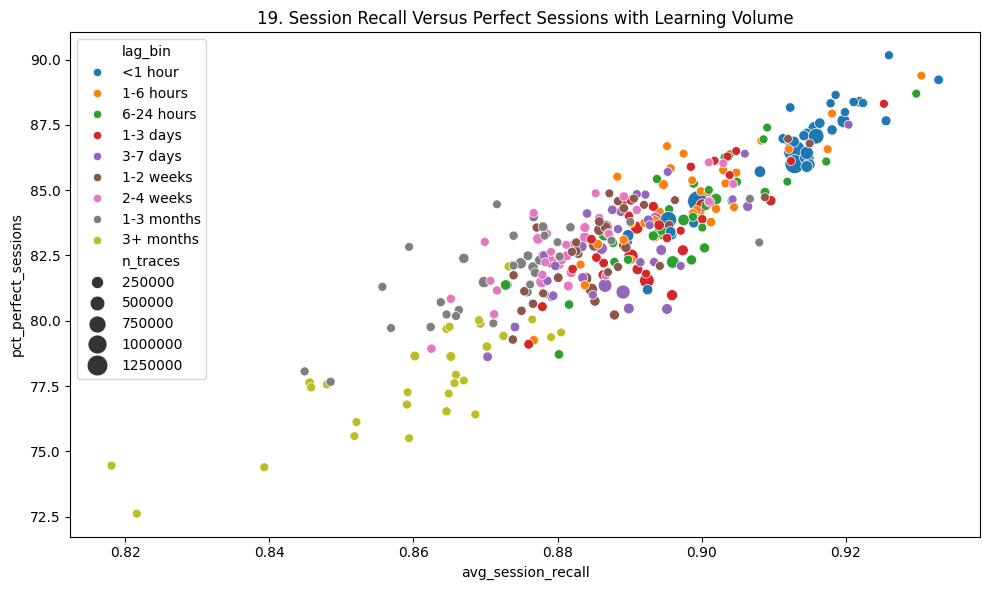

In [31]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='avg_session_recall', y='pct_perfect_sessions', hue='lag_bin', size='n_traces', sizes=(40,250))
plt.title(f'{plot_no}. Session Recall Versus Perfect Sessions with Learning Volume')
show_fig()
plot_no += 1

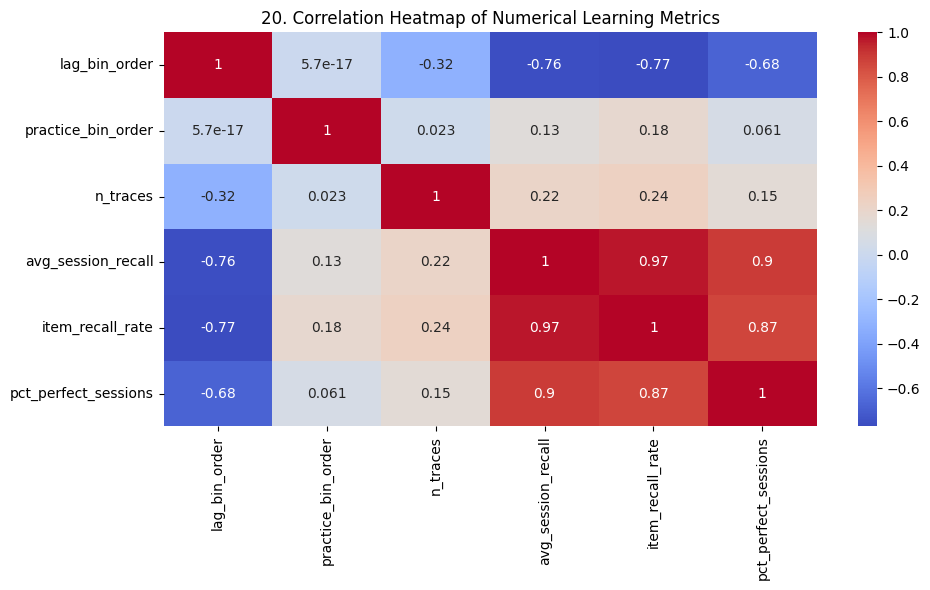

In [32]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Learning Metrics')
show_fig()
plot_no += 1

# Model Training

## Create a copy of dataset

In [33]:
data = df.copy()

## Encode categorical columns

In [34]:
label_encoders = {}
for col in data.select_dtypes(include='object').columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le

## Define features and target

In [35]:
X = data.drop(columns=['practice_bin'])
y = data['practice_bin']

## Split dataset into training and testing sets

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Create SVM pipeline with feature scaling

In [37]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(kernel='rbf', random_state=42))
])

## Train the model

In [38]:
model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', SVC(random_state=42))])

## Make predictions

In [39]:
y_pred = model.predict(X_test)

## Print model accuracy

In [40]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.2%}")

Accuracy Score: 95.16%


## Plot confusion matrix

<Figure size 800x600 with 0 Axes>

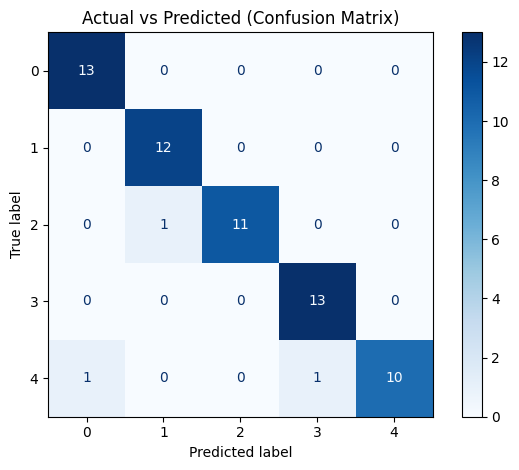

In [41]:
fig = plt.figure(figsize=(8,6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='Blues',
    values_format='d'
)
plt.title("Actual vs Predicted (Confusion Matrix)")
plt.tight_layout()
plt.show()